# PREDICCIÓN CHURN EMPRESA TELECOMUNICACIONES

En este ejercicio se emplean los datos de una compañia de telecomunicaciones extraídos de Kaggle. El objetivo del mismo es emplear varios algoritmos de ML y optimizarlos para tratar de encontrar un modelo que nos ayude a predicir las posibilidades que tiene de irse un cliente. En este tipo de empresas, lo difícil es conseguir un nuevo cliente por tanto lo mejor es siempre intentar retener clientes. Para buscar el mejor resultado, los algoritmos que se van a emplear son la regresión logística, el random forest y por último XGBoost.

El notebook tendrá el siguiente flujo de trabajo:
- 1. Preparación y limpieza de datos
- 2. Separación de train y test y escalado de datos
- 3. Modelado
- 4. Evaluación resultados modelo

El paso 3 y 4 se repiten una vez terminado un algoritmo para dar paso al siguiente.

Por último se empleará la librería shap para mostrar cuales son los factores más importantes para los clientes. Detectar los clientes que se van es importante, pero saber el motivo e intentar revertirlo es mucho más importante, tanto para los clientes actuales como para los clientes futuros.

### LIBRERÍAS

In [1]:
import pandas as pd
from ydata_profiling import ProfileReport
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,  classification_report, roc_curve, roc_auc_score, accuracy_score, precision_recall_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold, cross_val_score
from xgboost import XGBClassifier
import shap
import optuna
from optuna.samplers import TPESampler

%matplotlib inline

C:\Users\Iván\AppData\Local\Temp\ipykernel_31560\187913990.py:2: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [2]:
df = pd.read_csv('TelcoChurn.csv', sep=',', encoding='utf-8')
df.columns = df.columns.str.strip()  # eliminamos posibles espacios en blanco.
df.head(5).T

,0,1,2,3,4
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No phone service,No,No,No phone service,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No


### Diccionario variables

- customerID: identificación del cliente
- gender: género del cliente
- SeniorCitizen: indica si el cliente es mayor de 65. No: 0; Si: 1
- Partner: indica si está casado
- Dependents: indica si el cliente vive con alguien que dependa de el.
- tenure: indica el total de meses que el cliente lleva con el servicio contratado
- PhoneService: indica si el cliente tiene contratado el servicio de teléfono con la empresa.
- MultipleLines: indica si tiene más de una línea contratada.
- InternetService: indica si tiene servicio de internet contratado con la compañia y que tipo de servicio.
- OnlineSecurity: indica si el cliente tiene un servicio de seguridad online adicional.
- OnlineBackup: indica si el cliente tiene un servicio de recuperado adicional.
- DeviceProtection: indica si el cliente tiene un servicio de protección para el equipo de internet.
- TechSupport: indica si el cliente tiene un servicio de atención al cliente que reduce los tiempos de espera.
- StreamingTV: indica si el cliente tiene un servicio de streaming para reproducir contenidos de terceros en TV.
- StreamingMovies: indica si el cliente tiene un servicio de streaming para reproducir peliculas de terceros.
- Contract: indica el tipo de contrato. Pago mensual, año completo o dos años.
- PaperlessBilling: indica si el cliente recibe factura en papel.
- PaymentMethod: indica la forma de pago del cliente. Retiro bancario (automático), tarjeta de crédito (automático), recibo enviado por correo o recibo electrónico..
- MonthlyCharges: cargo mensual
- TotalCharges: cargo total hasta la fecha
- Churn: variable que indica si el cliente se ha dado de baja.

### FUNCIONES


In [3]:
def evaluar_modelo(modelo, X_train_input, y_train_input, X_test_input, y_test_input, threshold=.5, nombre_modelo='Nombre'):
    """
    Función para mostrar ROC AUC, Classification Report y Matriz de Confusión.
    Parámetros:
    modelo: modelo que se emplea
    X_test
    y_test
    X_train
    y_train
    threshold: umbral de corte para matriz de confusión
    nombre_modelo: nombre del modelo
    """

    # 1. Calculo probabilidades
    prob_train = modelo.predict_proba(X_train_input)[:,1]
    prob_test = modelo.predict_proba(X_test_input)[:,1]

    # 2. Calculo métrica ROC AUC
    auc_train = roc_auc_score(y_train_input, prob_train)
    auc_test = roc_auc_score(y_test_input, prob_test)

    # 3. Predicciones
    y_pred_test = (prob_test > threshold).astype(int)

    # 4. Printeo valores
    print(f'{nombre_modelo.upper()}')
    print(f'ROC AUC Train: {auc_train:.4f}')
    print(f'ROC AUC Test: {auc_test:.4f}')
    print('\nInforme Clasificación (Test):')
    print(classification_report(y_test_input, y_pred_test))

    # 5. Gráfico Matriz Confusión
    cm_input = confusion_matrix(y_test_input, y_pred_test)
    #fig_input, ax_input = plt.subplots(figsize=(6,5))
    disp_input = ConfusionMatrixDisplay(confusion_matrix=cm_input, display_labels=['No Churn', 'Churn'])
    disp_input.plot(cmap='Purples')
    plt.title(f'Matriz Confusión {nombre_modelo} - Umbral: {threshold}')
    plt.show()

    return prob_test

In [4]:
def comparar_curvas_roc(dict_resultados, y_real):
    plt.figure(figsize=(10, 7))
    
    colores = ['purple', 'green', 'blue']
    
    for i, (nombre, probs) in enumerate(dict_resultados.items()):
        fpr, tpr, _ = roc_curve(y_real, probs)
        auc = roc_auc_score(y_real, probs)
        
        plt.plot(fpr, tpr, label=f'{nombre} (AUC = {auc:.3f})', 
                 color=colores[i % len(colores)], lw=2)

    # Línea base (azar)
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
    plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
    plt.title('Comparativa Maestra de Modelos - Curva ROC')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.2)
    plt.show()

In [5]:
def optimizacion_optuna_xgb(X, y, n_trials=50):
    """
    Función para ejecutar la optimización de optuna
    Parámetros:
    X: conjunto X_train
    y: conjunto y_train
    n_trials: por defecto es 50, pero se puede configurar para hacer los intentos que se quieran.
    """
    
    def objective_xgboost(trial):
        """
        Función para buscar los mejores hiperparámetros en XGBoost.
        Optuna se encarga de ir comprobando resultados dentro de un rango de valores
        Parámetros:
        trial: nº de veces que hace combinaciones
        """
        # calculamos peso churn de forma intenra para cada pasada
        ratio_interno = y.value_counts()[0] / y.value_counts()[1]


        param = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'gamma': trial.suggest_float('gamma', 0, 0.2),
        
            # Parámetros fijos
            'objective': 'binary:logistic',
            'eval_metric': 'auc',
            'scale_pos_weight': ratio_interno, 
            'random_state': 42,
            'n_jobs': -1
        }

        model = XGBClassifier(**param)
        cv_strategy = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)
    
        # Optimizamos por AUC para asegurar una buena separación de clases
        scores = cross_val_score(model, X, y, cv=cv_strategy, scoring='roc_auc', n_jobs=-1)
        return np.mean(scores)


    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
    study.optimize(objective_xgboost, n_trials) #aplicamos función de búsqueda
    print(f"Mejor ROC AUC medio en CV: {study.best_value:.4f}")
    print(f"Mejores parámetros: {study.best_params}")
    return study

In [6]:
def optimizacion_optuna_rf(X, y, n_trials=50):
    """
    Función para ejecutar la optimización de optuna
    Parámetros:
    X: conjunto X_train
    y: conjunto y_train
    n_trials: por defecto es 50, pero se puede configurar para hacer los intentos que se quieran.
    """
    # 1. Calculamos los pesos para class_weight
    # El formato debe ser: {0: 1, 1: peso}
    # evitamos clase balanced de scikit para tener control sobre el ratio
    peso_churn = y.value_counts()[0] / y.value_counts()[1]
    ratio_dict = {0: 1, 1: peso_churn}

    def objective_rf(trial):
        """
        Función para buscar los mejores hiperparámetros en XGBoost.
        Optuna se encarga de ir comprobando resultados dentro de un rango de valores
        Parámetros:
        trial: nº de veces que hace combinaciones
        """

        param = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 800),
            'max_depth': trial.suggest_int('max_depth', 5, 25),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 4),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        
         # aplicamos diccionario de pesos
            'class_weight': ratio_dict, 
            'random_state': 42,
            'n_jobs': -1
        }

        model = RandomForestClassifier(**param)
        cv_strategy = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)
    
        # Optimizamos por ROC AUC para buena separación de clases
        scores = cross_val_score(model, X, y, cv=cv_strategy, scoring='roc_auc', n_jobs=-1)
        return np.mean(scores)

    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
    study.optimize(objective_rf, n_trials)
    print(f"Mejor ROC AUC medio en CV: {study.best_value:.4f}")
    print(f'Mejores parámetros: {study.best_params}')
    
    return study

## 1. Preparación y limpieza de datos

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Para que la regresión logística funciona sin problemas hay que codificar las variables tipo STR en INT. De forma previa, vamos a modificar la variable TotalCharges que es de tipo objeto y queremos que sea float.

In [8]:
df.TotalCharges = pd.to_numeric(df.TotalCharges, errors='coerce') # forzamos el cambio de tipo de valor para la columna totalcharges

print(df.TotalCharges.isnull().sum()) # comprobamos si hay valores nulos  

11


In [9]:
df[df['TotalCharges'].isna()] 

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


Tras observar los valores nulos, se puede ver que salen nulos porque es la primera vez que se han dado de alta en el servicio por tanto aún no han realizado ningún pago. La mejor opción en este escenario es imputar los valores con el valor 0.

In [10]:
df.TotalCharges = df.TotalCharges.fillna(0) # Imputamos valores nulos con 0

print(df.TotalCharges.isnull().sum()) # comprobamos que se han imputado de forma correcta los valores

0


In [11]:
profile = ProfileReport(df, title='EDA')

profile.to_notebook_iframe()
profile.to_file('EDA.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 21/21 [00:00<00:00, 381.97it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

### INSIGHTS DEL EDA

- El 84% de los clientes son menores de 65 años.
- El 90% de clientes tienen servicio telefónico contratado.
- Variables como MultipleLines, OnlineSecurity y similares donde las respuestas registradas son "Yes", "No" o "No phone service", vamos a simplificar los datos registrados cambiando "No phone service" por No para reducir el ruido de las variables y quedarnos con respuestas binarias.
- La variable objetivo "Churn" está desbalanceada representando No un 73.5% de los datos. A la hora de entrenar el modelo se empleará un "stratify".

In [12]:
cols_cambio = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'] # columnas en las que se reduce granularidad

df[cols_cambio] = df[cols_cambio].replace('No internet service', 'No')
df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')

print(df[cols_cambio].apply(lambda x:x.value_counts()))
print(df['MultipleLines'].value_counts())

print('-'*50)

print((df[cols_cambio].apply(lambda x:x.value_counts(normalize=True))*100).round(2))
print((df['MultipleLines'].value_counts(normalize=True)*100).round(2))

     OnlineSecurity  OnlineBackup  DeviceProtection  TechSupport  StreamingTV  \
No             5024          4614              4621         4999         4336   
Yes            2019          2429              2422         2044         2707   

     StreamingMovies  
No              4311  
Yes             2732  
MultipleLines
No     4072
Yes    2971
Name: count, dtype: int64
--------------------------------------------------
     OnlineSecurity  OnlineBackup  DeviceProtection  TechSupport  StreamingTV  \
No            71.33         65.51             65.61        70.98        61.56   
Yes           28.67         34.49             34.39        29.02        38.44   

     StreamingMovies  
No             61.21  
Yes            38.79  
MultipleLines
No     57.82
Yes    42.18
Name: proportion, dtype: float64


A continuación vamos a mapear las variables binarias para cambiar el tipo str a binario.

In [13]:
cols_binario = ['Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Churn']

df_binario = df.copy() # creamos copia del df original
mapeo = {'Yes': 1, 'No': 0} # creamos diccionario para realizar el mapeo de las columnas binarias

df_binario[cols_binario] = df[cols_binario].apply(lambda x: x.map(mapeo)) # aplicamos el mapeo
df_binario['gender'] = df['gender'].map({'Male': 1, 'Female':0}) # codificamos gender de forma individual

df_binario.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,1,0,1,0,0,DSL,0,...,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,1,0,0,0,34,1,0,DSL,1,...,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0
2,3668-QPYBK,1,0,0,0,2,1,0,DSL,1,...,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,1,0,0,0,45,0,0,DSL,1,...,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,0,0,0,0,2,1,0,Fiber optic,0,...,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1


Como InternetService, PaymentMethod y Contract son variables con más de 2 respuestas, hay que codificarlas de diferente manera mediante un OneHotEncoding. La respuesta más granular de estas variables puede ayudarnos a entender mejor el comportamiento de los clientes. Para evitar multicolinealidad en los algoritmos de ML, se aplica un drop_first=True. En este caso, vamos a aplicar un False ya que nos vamos a centrar en la matriz de correlación.

In [14]:
df_eda = pd.get_dummies(
    df_binario,
    columns=['InternetService', 'Contract', 'PaymentMethod'],
    drop_first=False,
    dtype=int
)

df_eda.head(5)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,0,1,0,1,0,0,0,1,...,1,0,0,1,0,0,0,0,1,0
1,5575-GNVDE,1,0,0,0,34,1,0,1,0,...,1,0,0,0,1,0,0,0,0,1
2,3668-QPYBK,1,0,0,0,2,1,0,1,1,...,1,0,0,1,0,0,0,0,0,1
3,7795-CFOCW,1,0,0,0,45,0,0,1,0,...,1,0,0,0,1,0,1,0,0,0
4,9237-HQITU,0,0,0,0,2,1,0,0,0,...,0,1,0,1,0,0,0,0,1,0


Vamos a crear una matriz de correlación entre las variables dummie creadas en el paso anterior y la variable objetivo Churn. El objetivo de esta matriz es obtener información con mayor detalle para poder entender los datos.

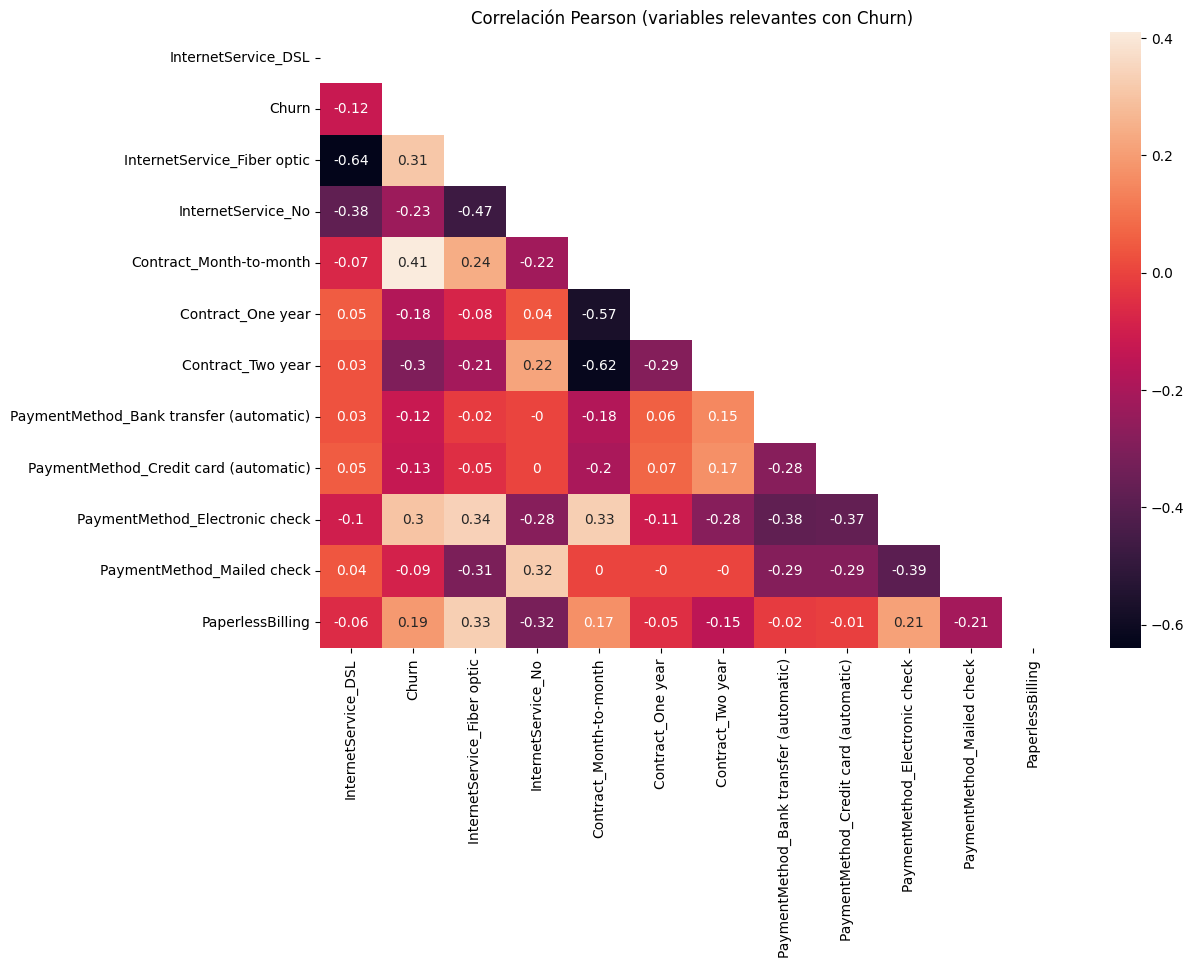

In [15]:
cols_corr_reduced = ['InternetService_DSL', 'Churn', 'InternetService_Fiber optic','InternetService_No','Contract_Month-to-month','Contract_One year',
                     'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)','PaymentMethod_Credit card (automatic)','PaymentMethod_Electronic check','PaymentMethod_Mailed check', 'PaperlessBilling']

matrix_corr_reduced = df_eda[cols_corr_reduced].corr().round(2)
mask = np.triu(np.ones_like(matrix_corr_reduced, dtype=bool)) # mascara para mostrar solo una diagonal
plt.figure(figsize=(12,8))
sns.heatmap(matrix_corr_reduced,
            annot=True,
            mask=mask)

plt.title('Correlación Pearson (variables relevantes con Churn)')
plt.show()

De la correlación se obtienen algunos datos interesantes. Es importante destacar que las relaciones detalladas no son muy fuertes, es decir, aunque nos pueden ayudar a entender porque un cliente se da de baja, el peso de las relaciones con churn no es muy elevado. Lo más probable es que el desbalanceo de clases en Churn tenga una gran influencia en que las relaciones sean débiles. Cabe destacar que esto tampoco tiene porque ser malo, ya que si solo un 30% de los clientes se dan de baja, quiere decir que el servicio ofrecido es bueno.

Los puntos destacados de la matriz de correlaciones en relación con la variable objetivo Churn son:
- Contrato Mes a Mes es el predictor más fuerte. No tener un contrato a largo plazo es el factor más determinante para irse.
- La Fibra Óptica tiene una relación positiva con el abandono, esto puede indicar que el servicio que ofrece la empresa tal vez sea peor que el de sus competidores.
- Por último, el pago mediante electronic check es otro punto a tener en cuenta para entender el motivo de que los clientes dejen de seguir con el servicio. Este método de pago requiere que el cliente realice una autorización manual cada mes del pago, lo que a la larga puede resultar en una tarea cansina para el cliente.

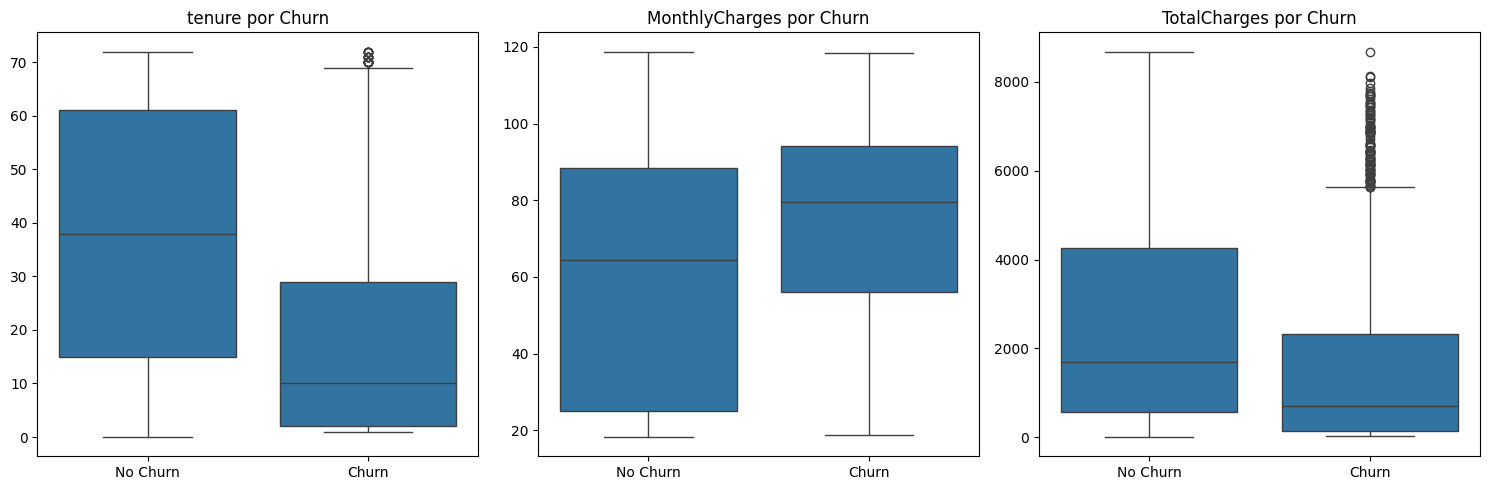

In [16]:
# Boxplots segmentados por Churn
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
for i, col in enumerate(['tenure', 'MonthlyCharges', 'TotalCharges']):
    sns.boxplot(data=df_eda, x='Churn', y=col, ax=ax[i])
    ax[i].set_title(f'{col} por Churn')
    ax[i].set_xticks([0,1])
    ax[i].set_xticklabels(['No Churn', 'Churn'])
    ax[i].set_xlabel('')
    ax[i].set_ylabel('')
plt.tight_layout()
plt.show()

Los diagramas de cajas ayudarán a enriquecer los datos obtenidos de la correlación. En relación a la antigüedad, se observa como los cliente que se van se concentran en un rango bajo con una mediana de 10 meses. Que la mediana se concentre en ese punto puede estar relacionado con un tipo de cliente que tiene un contrato mes a mes, reforzando la observación apreciada en la correlación.
Observando el cargo mensual, aquellos clientes que se van suelen tener cargos mensuales elevados con una mediama de 80 dolares. Puede tratarse de un tipo de cliente muy exigente que está dispuesto a pagar por un servicio siempre que este sea de buena calidad.
Por último, el dato que más destaca, los cargos totales. Se pueden observar una gran cantidad de outliers muy elevados en clientes que se van. Mientras que la mediana de los clientes que se van ronda los 1000 dolares, alrededor de los 5000 dolares de cargos totales empieza una serie de outliers. Esta observación debería hacer saltar todas las alarmas ya que un cliente que ha llegado a acumular una cantidad tan elevada de gasto también nos indica que estamos ante un cliente con elevada antigüedad y por tanto hay algún punto del servicio que no le está gustando.

Hacer un seguimiento de estos clientes será un punto muy importante a tener en cuenta.

In [17]:
filtrado_box =df_eda.query('TotalCharges >= 5000 and Churn == 1')
filtrado_box

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
13,0280-XJGEX,1,0,0,0,49,1,1,0,1,...,0,1,0,1,0,0,1,0,0,0
104,3192-NQECA,1,0,1,0,68,1,1,0,1,...,0,1,0,0,0,1,1,0,0,0
110,0486-HECZI,1,0,1,0,55,1,1,1,1,...,0,1,0,1,0,0,0,0,1,0
173,0691-JVSYA,0,0,1,0,53,1,0,0,0,...,0,1,0,0,1,0,1,0,0,0
276,4484-GLZOU,0,0,1,0,52,1,1,0,1,...,0,1,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6853,9079-YEXQJ,0,0,0,0,54,1,1,0,1,...,0,1,0,1,0,0,0,0,1,0
6945,6797-LNAQX,1,0,1,1,70,1,1,0,1,...,0,1,0,0,0,1,1,0,0,0
6952,6394-MFYNG,0,0,0,0,48,1,1,0,1,...,0,1,0,1,0,0,1,0,0,0
6972,6664-FPDAC,0,1,0,0,56,1,1,0,1,...,0,1,0,0,1,0,0,0,1,0


Filtrando el dataset se puede confirmar como los clientes que se van y tienen cargos totales altos muestran una elevada antigüedad

Filtrando el dataset, se encuentran 157 clientes con elevados cargos totales que deciden irse. Para despejar las dudas se va a filtrar el dataset anterior para los clientes que SI tiene fibra óptica contratada ya que era una de las variables que destacaba en relación a la decisión de darse de baja.

In [18]:
filtrado_box[filtrado_box['InternetService_Fiber optic'] == 1]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
13,0280-XJGEX,1,0,0,0,49,1,1,0,1,...,0,1,0,1,0,0,1,0,0,0
104,3192-NQECA,1,0,1,0,68,1,1,0,1,...,0,1,0,0,0,1,1,0,0,0
110,0486-HECZI,1,0,1,0,55,1,1,1,1,...,0,1,0,1,0,0,0,0,1,0
173,0691-JVSYA,0,0,1,0,53,1,0,0,0,...,0,1,0,0,1,0,1,0,0,0
276,4484-GLZOU,0,0,1,0,52,1,1,0,1,...,0,1,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6853,9079-YEXQJ,0,0,0,0,54,1,1,0,1,...,0,1,0,1,0,0,0,0,1,0
6945,6797-LNAQX,1,0,1,1,70,1,1,0,1,...,0,1,0,0,0,1,1,0,0,0
6952,6394-MFYNG,0,0,0,0,48,1,1,0,1,...,0,1,0,1,0,0,1,0,0,0
6972,6664-FPDAC,0,1,0,0,56,1,1,0,1,...,0,1,0,0,1,0,0,0,1,0


De 157 clientes se pasan a 151, lo que confirma los datos de la matriz de correlación, en donde la fibra óptica es un problema para retener clientes. Sin duda que este será un dato muy importante a tener en cuenta.

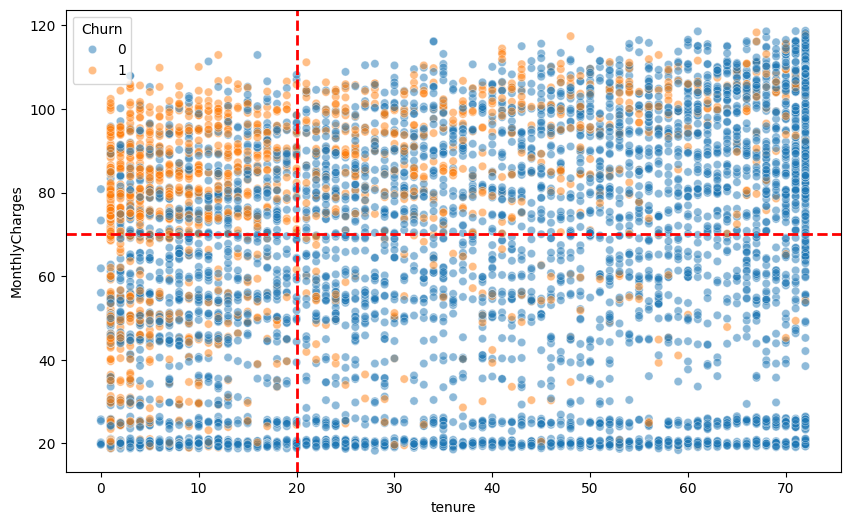

In [19]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_eda, x='tenure', y='MonthlyCharges', hue='Churn', alpha=.5)
plt.axhline(y=70, color='red', lw=2, ls='--')
plt.axvline(x=20, color='red', lw=2, ls='--')
plt.show()

Por último como paso previo a empezar el cálculo del algoritmo, vamos a visualizar como se comporta la variable objetivo en una nube de puntos empleando el cargo mensual y el tiempo que lleva el cliente con la suscripción. En el cuadrante superior izquierda podemos ver un patrón de comportamiento. Aquellos clientes con una tarifa mensual elevada y un período de suscripción bajo suelen ser los más propensos a abandonar el servicio.

# 2. TRAIN TEST SPLIT Y ESCALADO DE DATOS.

Una vez realizado el EDA, toca separar los datos en conjunto de entramiento y validación. Una vez separados, vamos a escalar las variables numéricas ya que la regresión logística es sensible a la escala de los datos. Esto será un factor a tener en cuenta para diferenciar entre la regresión logística y el random forest que calculemos más tarde, en donde, no es necesario escalar los datos ya que el random forest trabaja bien con los datos en escala original.

Es importante volver a calcular el dataset con las dummies pero en esta ocasión indicando drop_first=True para evitar un problema de multicolinealidad a la hora de implementar el algoritmo.

In [20]:
df_lr = pd.get_dummies(
    df_binario,
    columns=['InternetService', 'Contract', 'PaymentMethod'],
    drop_first=True,
    dtype=int
)

df_lr.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,0,1,0,1,0,0,0,1,...,29.85,29.85,0,0,0,0,0,0,1,0
1,5575-GNVDE,1,0,0,0,34,1,0,1,0,...,56.95,1889.50,0,0,0,1,0,0,0,1
2,3668-QPYBK,1,0,0,0,2,1,0,1,1,...,53.85,108.15,1,0,0,0,0,0,0,1
3,7795-CFOCW,1,0,0,0,45,0,0,1,0,...,42.30,1840.75,0,0,0,1,0,0,0,0
4,9237-HQITU,0,0,0,0,2,1,0,0,0,...,70.70,151.65,1,1,0,0,0,0,1,0


In [21]:
df_lr.set_index('customerID', inplace=True) # Ponemos el ID como índice del dataset

X = df_lr.drop('Churn', axis=1) # variables independientes
y = df_lr['Churn'] # variable dependiente

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=.2, # tamaño del conjunto de test
    random_state=42,  
    stratify=y # estratificamos variable y
)

In [22]:
scaler = StandardScaler()

scaler_cols = ['tenure', 'MonthlyCharges', 'TotalCharges'] # columnas que vamos a escalar

# creamos copia para regresión logistica debido a escalado de datos.
X_train_lr = X_train.copy() 
X_test_lr = X_test.copy()

# Ajustamos scaler solo a datos de entramiento (train)
X_train_lr[scaler_cols] = scaler.fit_transform(X_train_lr[scaler_cols])
# Transformamos datos de validación (test) con la media y desviación de los datos de entrenamiento (train)
X_test_lr[scaler_cols] = scaler.transform(X_test_lr[scaler_cols])


# 3. MODELADO

Con los datos ya separados, vamos a construir el primer modelo base.

In [23]:
# añadimos constante al modelo
X_train_sm = sm.add_constant(X_train_lr)
X_test_sm = sm.add_constant(X_test_lr)

# Ajustamos modelo
lr_model = sm.Logit(y_train, X_train_sm)
result = lr_model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.412375
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                 5634
Model:                          Logit   Df Residuals:                     5610
Method:                           MLE   Df Model:                           23
Date:                Mon, 11 May 2026   Pseudo R-squ.:                  0.2873
Time:                        16:30:25   Log-Likelihood:                -2323.3
converged:                       True   LL-Null:                       -3259.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
const                                    -4.5719      

### INSIGHTS

(Si p-value (0.05) > |z| variable estadísticamente significativa. Si p-value (0.05) < |z| variable estadísticamente insignificativa)

Las siguientes variables son candidatas a ser eliminadas ya que debido a su p-value y su coeficiente no aportan valor al modelo.

- gender: el p-value es mayor a 0.05 por tanto la variable no es estadísticamente significativa, es decir, a la hora de predecir si un cliente se va, ser hombre o mujer no determina nada. Esto también se ve reflejado en el valor del coeficiente 0.0243. 
- Partner: el p-value es mayor a 0.05, al igual que en el género del cliente, si tiene pareja no es relevante para saber si el cliente seguirá contratando el servicio. 
- OnlineSecurity: muestra un p-value mayor a 0.05, lo que indica que tener el servicio de seguridad online contratado no es estadísticamente significativo. El coeficiente que aporta la variable también refleja que apenas tiene efecto en la variable objetivo.
- TechSupport: el p-value de la variable como en los casos anteriores es muy superior a 0.05 y por tanto la variable no es significativa. Que el cliente tenga preferencia cuando hay probelmas técnicos no parece ser determinante.
- PaymentMethod_Credit card (automatic): en el caso de esta variable parece sorprendente que no sea significativa. La explicación es sencilla, como hemos indicado un drop_first=True, el modelo está comparando esta variable con PaymentMethod_Bank transfer (automatic) y como ambas opciones son automáticas, el modelo nos indica que le resulta irrelevante cualquiera de las dos opciones ya que en esencia están capturando lo mismo.
- PaymentMethod_Mailed check: la explicación lógica para indicar porque la variable no es significativa sería que podemos estar ante un método de pago que puede emplear la gente mayor principalmente, pero filtrando los datos tenemos que solo 94 personas mayores emplean este método, descartando esta teoría. La conclusión a la que se llega es que el modelo no detecta ningún comportamiento especial en esta variable por tanto decide descartarla.
- PhoneService
- OnlineBackup
- DeviceProtection


Ahora vamos con las variables que el modelo SI destaca como importantes.

- InternetService_Fiber Optic: el p-value es estadísticamente significativo, por tanto es una variable que nos ayuda a explicar porque los clientes se van. Lo más importante es observar el coeficiente que acompaña la variable, 2.8960, un valor muy elevado y que por tanto nos indica que tener contratado este servicio es un gran factor determinante para anular el servicio con la empresa. Esto nos puede llevar a la conclusión de que a pesar de que un cliente pueda estar satisfecho con el servicio a nivel general, la calidad de internet puede ser menor a la esperada.
- Contract_Two year: esta variable al igual que el contrato a un año resulta estadísticamente significativa. El coeficiente que acompaña a esta variable, tiene bastante peso, -1.3740, indicando que aquellos clientes que firman contratos a largo plazo tienen menor probabilidad cancelar su contrato con la emrpesa.
- tenure: en relación a la antigüedad, esta es estadísticamente significativa y tiene un coeficiente que nos indica que por cada unidad adicional de antigüedad, es decir, por cada mes adicional, el riesgo de fuga cae significativamente en -1.3075.
- PaymentMethod_Electronic check: aunque no tiene un gran peso a nivel coeficiente, es una variable determinante para la variable objetivo. Este método de pago requiere realizar un cheque bancario cada mes de forma manual, lo que puede estar relacionado con un perfil de cliente más volátil y principalmente centrado en clientes con contrato mes a mes. Esta relación se puede ver en la matriz de correlación, donde devuelve un coeficiente de 0.33 que resulta bastante elevado para nuestro modelo.

Por otro lado, podemos destacar la variable **MonthlyCharges** con coeficiente negativo, la interpretación sería que por cada unidad que aumenta la variable, se reduce el abandono en -2.5389 lo que no tiene sentido desde el punto de vista del cliente. Si el pago de tu servicio mensual aumenta lo más probable es que decidas irte a otra empresa. Este coeficiente puede ser un indicativo de multicolinealidad ya que la variable **TotalCharges** en cierta medida ya refleja lo que contiene la variable que destacamos. Multiplicando la antigüedad por la tarifa mensual podemos obtener los mismos datos.

En esta situación lo ideal es eliminar la variable **TotalCharges** pero antes de tomar una decisión vamos a aplicar un Factor de Inflación de la Varianza (VIF) para cuantificar esta multicolinealidad.

En el EDA realizado con la librería ydata_profiling para la variable **TotalCharges** podemos encontrar una alta correlación con **MonthlyCharges** de 0.63 y con **tenure** de 0.89. Este es un indicativo de que es una variable candidata a eliminar pero para confirmarlo miraremos el VIF.

Para calcular el VIF emplearemos los datos sin escalar, por tanto vamos a extraer los mismos del primer dataset importado.

In [24]:
vif_features = df[scaler_cols] # empleamos lista con las variables ya almacenadas para escalar

vif_data = pd.DataFrame() # almacenamos resultados en un dataframe

vif_data['Variable'] = vif_features.columns # añadimos columnas al dataframe
vif_data['VIF'] = [variance_inflation_factor(vif_features.values, i) for i in range(len(vif_features.columns))] # bucle mediante comprensión de listas
print(vif_data)

         Variable       VIF
0          tenure  6.332328
1  MonthlyCharges  3.355660
2    TotalCharges  8.075070


Podemos comprobar como **TotalCharges** tiene un valor próximo a 10, lo que nos indica que es candidata a ser eliminada.

Vamos a recalcular el VIF eliminando la variable de **TotalCharges**

In [25]:
scaler_cols_2 = [c for c in scaler_cols if c != 'TotalCharges'] # eliminamos TotalCharges

vif_features_2 = df[scaler_cols_2]
vif_data_2 = pd.DataFrame()
vif_data_2['Variable'] = vif_features_2.columns # añadimos columnas al dataframe
vif_data_2['VIF'] = [variance_inflation_factor(vif_features_2.values, i) for i in range(len(vif_features_2.columns))] # bucle mediante comprensión de listas
print(vif_data_2)

         Variable       VIF
0          tenure  2.612607
1  MonthlyCharges  2.612607


Tras haber recalculado nuestros datos, podemos observar como el ruido que ocasionaba **TotalCharges** practicamente desaparece.

Con esta confirmación procedemos a eliminar las variables que no son significativas y también TotalCharges y recalculamos la regresión logística.

In [26]:
# Variables a eliminar
features_drop = ['TotalCharges', 'gender', 'Partner', 'OnlineSecurity', 'OnlineBackup', 'TechSupport', 'PhoneService', 'PaymentMethod_Mailed check', 'PaymentMethod_Credit card (automatic)',
                 'DeviceProtection']

# Actualización de variables train_test_split
X_train_lr_2 = X_train_lr.drop(columns=features_drop, errors='ignore')
X_test_lr_2 = X_test_lr.drop(columns=features_drop, errors='ignore')

# Añadimos constante

X_train_2_sm = sm.add_constant(X_train_lr_2)
X_test_2_sm = sm.add_constant(X_test_lr_2)

# Entrenamiento nuevo modelo

lr_model_2 = sm.Logit(y_train, X_train_2_sm)
result_2 = lr_model_2.fit()

print(result_2.summary())

Optimization terminated successfully.
         Current function value: 0.414926
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                 5634
Model:                          Logit   Df Residuals:                     5620
Method:                           MLE   Df Model:                           13
Date:                Mon, 11 May 2026   Pseudo R-squ.:                  0.2829
Time:                        16:30:25   Log-Likelihood:                -2337.7
converged:                       True   LL-Null:                       -3259.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -2.6241      0.157    -16.743     

Como se puede ver, el nuevo modelo mejora de forma drástica al anterior. Ahora la única variable que resulta NO ser significativa es SeniorCitizen que a pesar de eso, vamos a conservarla en el modelo. Esta decisión viene determinada porque este segmento de la población en general suele tener comportamientos distintos y por tanto la solución que se puede presentar no es la misma que para el resto de la población.

En el primer análisis de resultados realizado, se llega a la conclusión de que el coeficiente negativo de **MonthlyCharges** carece de sentido, lo cúal es lógico, pero ahora que hemos eliminado el problema de multicolinealidad del modelo podemos observar que aunque sigue siendo un coeficiente negativo, este es menos pronunciado. La explicación que se encuentra es que aunque en buena medida una mayor cuota implica que el cliente esté menos satisfecho, al mismo tiempo también implica que a mayor cuota, mayor cantidad de servicios contratados y por tanto se traslada en una mayor satisfacción por parte del cliente y un mayor compromiso a largo plazo. No es lo mismo cambiarse de compañía y solo tener que cambiar una línea telefónica a cambiar de compañía y tener que hacer un cambio de todos los servicios contratados.

Por otro lado, podemos ver como el contrato a dos años y no tener servicio de internet contratado son las variables más fuertes que explican la retención del cliente, siendo la fibra óptica el principal handicap a la hora de irse.

### 4. MÉTRICAS

Métricas de Rendimiento
Accuracy Score: 0.7928
ROC AUC Test: 0.8391
ROC AUC Train: 0.8465

Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.62      0.55      0.58       374

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409



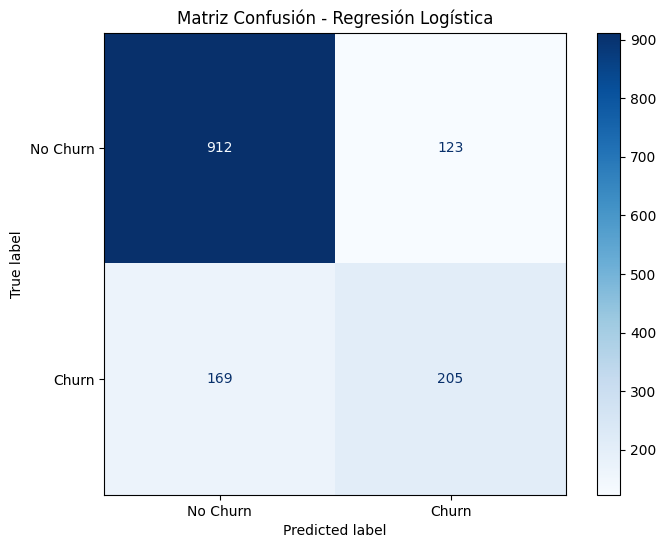

In [27]:
# Predicción y probabilidades
y_probs_train = result_2.predict(X_train_2_sm)
y_pred_train = (y_probs_train > .5).astype(int)

y_probs_test = result_2.predict(X_test_2_sm)
y_pred_test = (y_probs_test > 0.5).astype(int)

score_auc = roc_auc_score(y_test, y_probs_test)
score_accu = accuracy_score(y_test, y_pred_test)
print(f'Métricas de Rendimiento')
print(f'Accuracy Score: {score_accu:.4f}')
print(f'ROC AUC Test: {score_auc:.4f}')
print(f'ROC AUC Train: {roc_auc_score(y_train, y_probs_train):.4f}')
print('\nInforme de Clasificación:')
print(classification_report(y_test, y_pred_test))

# Visualización Matriz de confusión

fig, ax = plt.subplots(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues', ax=ax)
plt.title('Matriz Confusión - Regresión Logística')
plt.show()

La primera métrica en la que nos vamos a fijar es el **Accuracy Score** que tiene un resultado de 0.79 y nos indica el desempeño del modelo. La métrica lo que dice es cuantos aciertos ha tenido el modelo sobre el total de datos. El principal problema de emplear esta métrica en este escenario es que estamos ante un dataset desbalanceado y por tanto no es una buena referencia. 

Para los valores con etiqueta 0, "No Churn", tenemos:
- precision: 0.84. La precision es una métrica que nos indica que porcentaje de todo lo clasificado como positivo, es realmente positivo. Es decir, en este caso, de todo lo clasificado como "No Churn" que porcentaje es "No Churn". 
- recall: 0.88. Nos indica que proporción de todos los valores positivos, han sido clasificados como positivos. Es decir, de todos los valores que se han clasificado como No Churn, que proporción pertenece a No Churn.
- f1-score: 0.86. Esta métrica es una media armónica entre precision y recall. 

Nota: lo que se llama positivo en las explicaciones anteriores es una apreaciación teórica. En este ejercicio el valor positivo para nosotros es Churn ya que es la variable que buscamos medir.

La matriz de confusión en sklearn a diferencia de lo que se muestra en los manuales, invierte los ejes, por tanto tenemos:
- True Positive: 205
- False Negative: 169
- False Positive: 123
- True Negative: 912

En este momento, el modelo se encuentra con un umbral balanceado del 50%. Uno de los puntos que más nos preocupa es el False Negative, se puede observar como la predicción del modelo es que esos clientes no se van a ir, pero la realidad es que son clientes que si se han ido. En otras palabras, la empresa está perdiendo un 45% de los clientes sin darse cuenta. 
Por otro lado, el modelo detecta 205 clientes que se van a ir. En este segmento es donde tenemos conocimiento para actuar y por tanto evitar que se vayan a la competencia.
Por último, tenemos lo que se puede llamar falsa alarma. El modelo ha clasificado a estos clientes como que se van pero en verdad no tienen pensado irse.

Es importante tener en cuenta que los valores presentes van a depender del enfoque que quiera adoptar la empresa. Si quieren un enfoque conservador en riesgos, pero agresivo en detección la estrategia es bajar el umbral. Si bajamos el umbral a un 20% entonces el modelo clasificará como fuga cuando se detecte un 20% de posibilidad de fuga en el cliente. Por el contrario, si la apuesta es ser agresivo en riesgo y conservador en detección, lo que hacemos es subir ese umbral a un 80% por ejemplo. En este escenario la alerta solo saltará en el momento en que las posibilidades de salida del cliente sean del 80%.

Una forma de decidir si un umbral es mejor que otro es realizar una ecuación de costes. 
- CosteTotal = (False Negative * Coste perdida) + (False Positve * Coste Campaña)

En el sector de las telecompañias, conseguir un nuevo cliente es más difícil que mantener a uno que ya tiene los servicios contratados, por tanto reducir el umbral y gastar recursos adicionales en clientes que no tienen pensado irse pero el modelo clásifica como riesgo puede ser más beneficioso.

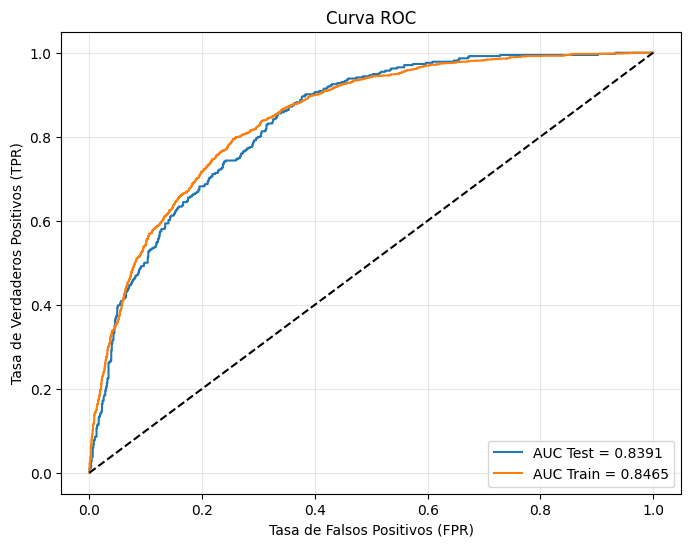

In [28]:
fpr, tpr, _ = roc_curve(y_test, y_probs_test)
fpr2, tpr2, _ = roc_curve(y_train, y_probs_train)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC Test = {score_auc:.4f}')
plt.plot(fpr2,tpr2, label=f'AUC Train = {roc_auc_score(y_train, y_probs_train):.4f}')
plt.plot([0, 1], [0, 1], 'k--') # Línea diagonal de referencia
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

Observando el AUC para Train y Test se puede decir que el modelo no presenta overfitting. Ambos valores son muy similares y eso es un buen indicativo sobre la robustez del modelo. Si el AUC de train fuese muy elevado en comparación al de test el modelo estaría presentando un sobreajuste, es decir, en vez de aprender estaría memorizando los datos y por tanto no sería capaz de realizar predicciones fuera de el patrón estudiado. En otras palabras, el modelo no sería capaz de generalizar.

La métrica AUC lo que hace es evaluar la capacidad que tiene el algoritmo para separar las clases independientemente del umbral que se hubiese seleccionado. En el eje Y se representa el porcentaje de clientes que realmente se van y que el modelo logra detectar. Se busca que el valor sea lo más cercano a 1 posible. En el eje X se muestra el porcentaje de clientes que se quedan pero que el modelo marca erróneamente como fuga.

La curva diagonal del gráfico representa el 50%, es decir, si el AUC que devuelve el modelo es igual o inferior a 0.5, entonces es indiferente predecir de forma aleatoria que se obtendría el mismo acierto.

### 5. RANDOM FOREST

A continuación vamos a construir un Random Forest. La regresión logística es un buen punto de partida, es un modelo simple y muy fácil de interpretar, el objetivo de construir un RF es comprobar como se comportan los datos. Si los datos se comportan de forma lineal, la LR posiblimente resulte suficiente para realizar predicciones. Si por el contrario, el RF devuelve unas mejores métricas que la LR, lo más probable es que la estructura de los datos sea NO lineal y por tanto el modelo lineal no es capaz de capturar todas las interacciones entre las variables.

OOB Score: 0.7820
RANDOMFOREST
ROC AUC Train: 0.9444
ROC AUC Test: 0.8433

Informe Clasificación (Test):
              precision    recall  f1-score   support

           0       0.89      0.79      0.84      1035
           1       0.55      0.72      0.62       374

    accuracy                           0.77      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.80      0.77      0.78      1409



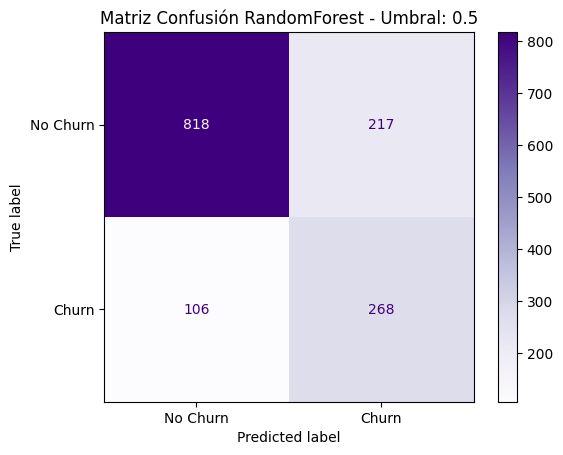

In [29]:
# Calculamos el ratio de desbalanceo
ratio_manual = y_train.value_counts()[0] / y_train.value_counts()[1]
pesos = {0: 1, 1: ratio_manual} # diccionario para pesos

rf_model = RandomForestClassifier(n_estimators=100,
                                  max_depth=10,
                                  random_state=42,
                                  class_weight=pesos,
                                  oob_score=True)

rf_model.fit(X_train, y_train)
print(f'OOB Score: {rf_model.oob_score_:.4f}')
rf = evaluar_modelo(rf_model, X_train, y_train, X_test, y_test, threshold=.5, nombre_modelo='RandomForest')

Comprobando el valor de ROC AUC para train y test, el primer modelo RF se puede catalogar como desastre, pero era algo esperable. Este modelo sin ningún tipo de ajuste está memorizando y por tanto presentando overfitting. 

El overfitting no solo se aprecia por la diferencia entre el ROC AUC de train y test, el OOB Score también nos ayuda a determinar este problema. El RF entrena cada árbol con una submuestra distinta de los datos, una técnica que se llama bagging, donde el OOB evalúa cada fila haciendo uso de los árboles que no se han empleado. El resultado del OOB se puede interpretar como la precisión real esperada del modelo ante nuevos datos. Ante la memorización de los datos que hizo el modelo con el conjunto de entrenamiento, el OOB ha servido como una alerta temprana para determinar que algo no va bien.

Aunque el modelo llega a predecir más clientes con riesgo de fuga que en la regresión logística, esto no tiene utilidad debido a que no es un modelo que sea capaz de generalizar, es decir, no es robusto. Lo que si nos permite detectar este cambio de predicción es que los datos presentan relaciones NO lineales que la regresión logística no puede capturar.

Como paso lógico, se van a ajustar los hiperparámetros para buscar optimizar el modelo. Para esta optimización se va emplear la librería Optuna, un método de optimización en donde la búsqueda de los parámetros resulta más sencilla ya que a diferencia de GridSearchCV en donde se prueban todas las combinaciones posibles, en Optuna se asigna un límite inferior y superior y el algoritmo se encarga de ir probando diferentes combinaciones dentro de esos límites. Para hacer que el resultado sea más robusto, se aplica un Cross-Validation interno.

**NOTA**: la función optimizacion_optuna_rf se encuentra al principio del notebook y es la encargada de buscar los mejores parámetros.

### Modelo Optimizado

In [30]:
estudio_rf = optimizacion_optuna_rf(X_train,y_train, 50)
rf_optimizado = RandomForestClassifier(**estudio_rf.best_params, class_weight=pesos, random_state=42, oob_score=True)
rf_optimizado.fit(X_train,y_train)

[I 2026-05-11 16:30:26,259] A new study created in memory with name: no-name-40e835f9-a150-4840-aca9-9aad42f2764e
[I 2026-05-11 16:30:31,741] Trial 0 finished with value: 0.8431236486369486 and parameters: {'n_estimators': 362, 'max_depth': 24, 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.8431236486369486.
[I 2026-05-11 16:30:34,353] Trial 1 finished with value: 0.8430068543550667 and parameters: {'n_estimators': 140, 'max_depth': 23, 'min_samples_split': 7, 'min_samples_leaf': 3, 'max_features': 'log2'}. Best is trial 0 with value: 0.8431236486369486.
[I 2026-05-11 16:30:44,713] Trial 2 finished with value: 0.8463994205313298 and parameters: {'n_estimators': 683, 'max_depth': 9, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 2 with value: 0.8463994205313298.
[I 2026-05-11 16:30:51,221] Trial 3 finished with value: 0.8447375955994005 and parameters: {'n_estimators': 402, 'max_depth': 11, 'mi

Mejor ROC AUC medio en CV: 0.8478
Mejores parámetros: {'n_estimators': 525, 'max_depth': 8, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt'}


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",525
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

OOB Score: 0.7671
RF OPTIMIZADO
ROC AUC Train: 0.8949
ROC AUC Test: 0.8471

Informe Clasificación (Test):
              precision    recall  f1-score   support

           0       0.91      0.75      0.82      1035
           1       0.54      0.78      0.64       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409



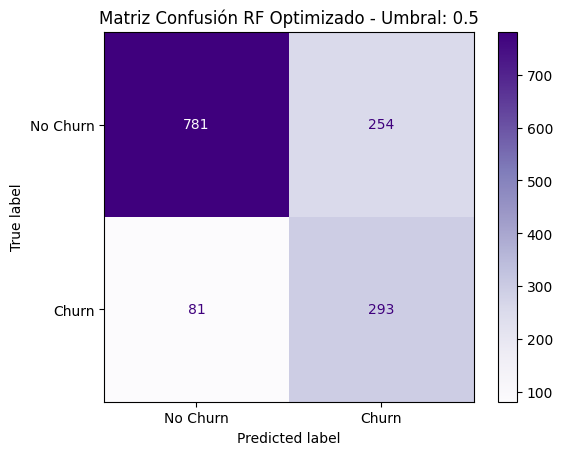

In [31]:
print(f'OOB Score: {rf_optimizado.oob_score_:.4f}')
rf_opt_resultados = evaluar_modelo(rf_optimizado, X_train, y_train, X_test, y_test, threshold=.5, nombre_modelo='RF Optimizado')

Una vez que se han obtenido los mejores parámetros y han sido aplicados al modelo, se observa como el ROC AUC del conjunto de entrenamiento baja de forma drástica, reduciendo el overfitting que presentaba el modelo inicial. Ahora el modelo deja de ser tan optimista y empieza a generalizar más. Una vez más el OOB vuelve a ser un aviso de alerta temprana, a pesar de reducir el overfitting, si se proporcionan datos nuevos al modelo, tendrá una capacidad de generalización del 76% aprox.

Si nos fijamos en la matriz de confusión, en comparación al modelo base, se aprecia como los falsos negativos (81) se han reducido, aunque esta redución conlleva un coste que es el aumento de los falsos positivos (254). Para el tipo de problema que tenemos presente, es un buen precio a pagar. El coste de una campaña de retención es significativamente menor al coste de perder un cliente, es preferible que el equipo de marketing llame a personas que no tienen pensado cambiar de compañía a que se escape un elevado número de clientes. 

Como el modelo actual hace uso de todas las variables que contiene el dataset, para intentar reducir la complejidad se van a extraer las 10 variables más importantes para el modelo e intentar construir un nuevo modelo reducido que presente menor complejidad y por tanto sea más fácil de llevar a producción. A la hora de implementar soluciones, cuanto más ligero sea el modelo, menor coste implicará.
Para determinar estas 10 variables, se hace uso de la librería SHAP. Esta librería determina cuánto contribuye exactamente cada variable a que se produzca o evite la fuga del cliente. SHAP toma una predicción base, como es el promedio de Churn de todos los clientes y va analizando esta predicción a medida que se añade una nueva variable. Cada variable recibe un valor, si este es positivo indica que la variable empuja al cliente hacia la fuga y si es negativo, aleja al cliente de la fuga. 
La gran ventaja que presenta esta librería no solo es saber que variables son las más importantes para el modelo, sinó que nos permite saber en que medida afecta cada variable de forma individual al objetivo, permitiendo que el equipo de marketing pueda desarrollar distintas estrategias a la hora de abordar a los clientes para evitar su fuga.

In [32]:
# 1. Instanciamos modelo y calculamos valores
explainer = shap.TreeExplainer(rf_optimizado)
shap_values = explainer.shap_values(X_test)

# 2. SELECCIÓN DE CLASE: 
# En RF de sklearn, shap_values[1] son los valores para la clase 'Churn'
# Usamos np.abs().mean(0) para obtener la importancia global de cada variable
if isinstance(shap_values, list):
    vals = np.abs(shap_values[1]).mean(0)
else:
    vals = np.abs(shap_values[:, :, 1]).mean(0) if len(shap_values.shape) == 3 else np.abs(shap_values).mean(0)

# 3. Creamos el DataFrame
feature_importance = pd.DataFrame(list(zip(X_train.columns, vals)), 
                                  columns=['col_name', 'feature_importance_vals'])


feature_importance.sort_values(by='feature_importance_vals', ascending=False, inplace=True)
print(feature_importance.head(10))

top_10_rf = feature_importance['col_name'].head(10).tolist()

X_train_rf = X_train[top_10_rf]
X_test_rf = X_test[top_10_rf]

                          col_name  feature_importance_vals
16     InternetService_Fiber optic                 0.073003
4                           tenure                 0.071634
19               Contract_Two year                 0.065048
21  PaymentMethod_Electronic check                 0.037788
15                    TotalCharges                 0.037698
17              InternetService_No                 0.034251
18               Contract_One year                 0.032073
14                  MonthlyCharges                 0.031192
7                   OnlineSecurity                 0.020662
13                PaperlessBilling                 0.019644


### Modelo Optimizado con 10 Variables

Una vez extraídas las 10 variables más importantes, procedemos a construir el modelo una vez más

In [33]:
estudio_rf_10 = optimizacion_optuna_rf(X_train_rf, y_train, 50)

rf_optimizado_10 = RandomForestClassifier(**estudio_rf_10.best_params, class_weight=pesos, random_state=42, oob_score=True)
rf_optimizado_10.fit(X_train_rf,y_train)

[I 2026-05-11 16:34:59,245] A new study created in memory with name: no-name-a043f3c1-8b47-4694-a706-34a1f200b2f9
[I 2026-05-11 16:35:01,232] Trial 0 finished with value: 0.8336159012524723 and parameters: {'n_estimators': 362, 'max_depth': 24, 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.8336159012524723.
[I 2026-05-11 16:35:02,075] Trial 1 finished with value: 0.83303433335526 and parameters: {'n_estimators': 140, 'max_depth': 23, 'min_samples_split': 7, 'min_samples_leaf': 3, 'max_features': 'log2'}. Best is trial 0 with value: 0.8336159012524723.
[I 2026-05-11 16:35:05,225] Trial 2 finished with value: 0.8423595759680248 and parameters: {'n_estimators': 683, 'max_depth': 9, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 2 with value: 0.8423595759680248.
[I 2026-05-11 16:35:07,315] Trial 3 finished with value: 0.838420949826993 and parameters: {'n_estimators': 402, 'max_depth': 11, 'min_s

Mejor ROC AUC medio en CV: 0.8454
Mejores parámetros: {'n_estimators': 239, 'max_depth': 7, 'min_samples_split': 7, 'min_samples_leaf': 3, 'max_features': 'sqrt'}


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",239
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",7
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

OOB SCORE: 0.7613
RF OPT 10 VAR
ROC AUC Train: 0.8803
ROC AUC Test: 0.8423

Informe Clasificación (Test):
              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1035
           1       0.53      0.78      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409



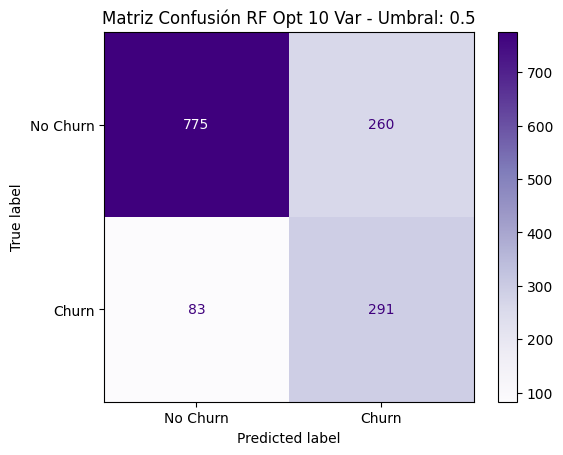

In [34]:
print(f'OOB SCORE: {rf_optimizado_10.oob_score_:.4f}')
rf_10_features = evaluar_modelo(rf_optimizado_10, X_train_rf, y_train, X_test_rf, y_test, threshold=.5, nombre_modelo='RF Opt 10 Var')

Una vez cosntruído el modelo con las 10 variables más importantes y observado los resultados obtenidos, se puede ver como este modelo reducido es capaz de lograr una mayor generalización logrando reducir el overfitting. Estamos ante el modelo que ha devuelto una mayor convergencia entre ROC AUC de train y test, lo que es una muy buena señal. En cuanto al OOB, este se mantiene constante, dando lugar a una capacidad de generalización similar para nuevos datos.

Observando la matriz de confusión, aunque el recall de la clase 1 que es la métrica que más nos interesa se mantiene igual, la capacidad de discriminación ha empeorado un poco. Este empeoramiento no es preocupante ya que la diferencia es mínima por tanto el impacto causado se compensa con la reducción de complejidad del modelo.

Es importante tener en cuenta que hasta el momento los resultados presentados en la matriz de confusión se encuentran determinados por un umbral del 50%, es decir, estamos siendo "estrictos" a la hora de clasificar a los clientes, aquellos que no alcancen un 50% de probabilidades no logran clasificar. Si el equipo de marketing quisiera una estrategia menos agresiva sólo habría que cambiar el umbral a un menor porcentaje. El peaje a pagar si se reduce el umbral es un aumento de los FP.

Para enriquecer el ejercicio e intentar reducir aún más la complejidad del modelado, se va a construir un XGBoost.

### XGBoost

Al igual que con el RF, el proceso de construcción será igual. Pasaremos de un modelo genérico a un modelo más optimizado. De esta forma será posible evaluar como se comporta el **Learning Rate**.

XGBOOST
ROC AUC Train: 0.9881
ROC AUC Test: 0.8210

Informe Clasificación (Test):
              precision    recall  f1-score   support

           0       0.87      0.80      0.84      1035
           1       0.55      0.68      0.61       374

    accuracy                           0.77      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.77      0.78      1409



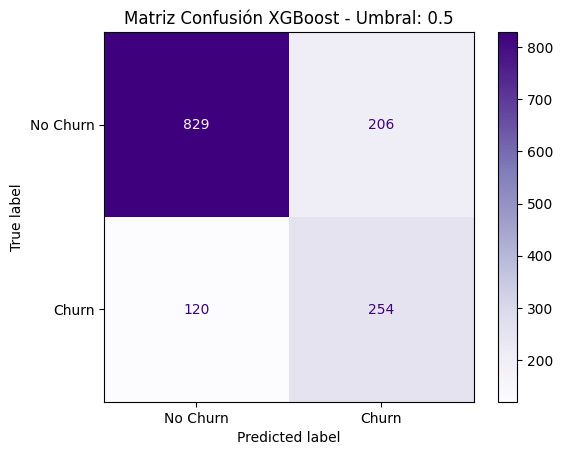

In [35]:
# Se calcula el desbalanceo a mano
ratio_xg = y_train.value_counts()[0] / y_train.value_counts()[1]

xg_model = XGBClassifier(
    random_state = 42, 
    scale_pos_weight=ratio_xg, # indicamos como se encuentran de balanceadas las clases
    eval_metric='auc', # métrica que empleará el modelo medir el rendimiento en el entrenamiento
    objective='binary:logistic' # define la tarea del modelo. Concretamente clasificación binaria y resultado de probabilidad logística
)

# Entrenamos modelo
xg_model.fit(X_train, y_train)

xg = evaluar_modelo(xg_model, X_train, y_train, X_test, y_test, threshold=.5, nombre_modelo='XGBoost')

El primer modelo de XGBoost al igual que ocurre con el RF presenta un severo overfitting. Aunque esto cabe esperar que siempre ocurra, es un paso a realizar para tener un punto de partida para ir mejorando el modelo. A diferencia del RF, este modelo utiliza un parámetro de aprendizaje llamado **learning rate**. El valor que presenta por defecto es muy agresivo, como el modelo se basa en el descenso del gradiente, este valor provoca que el modelo salte de un punto a otro memorizando los datos en vez de buscar un camino paso a paso en donde va aprendiendo de los datos. 

Para corregir esta situación, hay que optimizar el modelo.

Mientras que en el RF los árboles se construyen de forma paralela, en el XGBoost estos se construyen de forma secuencial. Al construirse de forma secuencial, el modelo lo que hace es ir aprendiendo de cada árbol anterior para tratar de mejorar el siguiente.

Para esta optimización, se empleará la regularización **gamma** que consiste en medir la ganancia de información al crear una nueva rama en el árbol. Si la ganancia de la división es mayor que el valor de gamma indicado, se realiza un nuevo corte. Por el contrario, si la ganancia es menor que el valor indicado, se descarta el corte y ese nodo se convierte en una nueva hoja. Esta opción permite evitar la construcción de árboles demasiado profundos, así, un menor número de cortes permite obtener un modelo mucho más simple que se traduce en una mejor capacidad de generalización.

# MODELO OPTIMIZADO

In [36]:
estudio_xgb = optimizacion_optuna_xgb(X_train,y_train,50)

xgb_opt = XGBClassifier(**estudio_xgb.best_params, scale_pos_weight=ratio_xg, random_state=42)
xgb_opt.fit(X_train, y_train)

[I 2026-05-11 16:36:24,631] A new study created in memory with name: no-name-7c8a7fc4-a6f4-4f1a-b0bf-08fa6a133b5e
[I 2026-05-11 16:36:26,558] Trial 0 finished with value: 0.8058683668965095 and parameters: {'n_estimators': 437, 'max_depth': 10, 'learning_rate': 0.1205712628744377, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'gamma': 0.031198904067240532}. Best is trial 0 with value: 0.8058683668965095.
[I 2026-05-11 16:36:27,098] Trial 1 finished with value: 0.828441148283805 and parameters: {'n_estimators': 152, 'max_depth': 9, 'learning_rate': 0.07725378389307355, 'subsample': 0.8540362888980227, 'colsample_bytree': 0.5102922471479012, 'gamma': 0.19398197043239887}. Best is trial 1 with value: 0.828441148283805.
[I 2026-05-11 16:36:28,094] Trial 2 finished with value: 0.8439700605248751 and parameters: {'n_estimators': 850, 'max_depth': 4, 'learning_rate': 0.01855998084649059, 'subsample': 0.5917022549267169, 'colsample_bytree': 0.6521211214797689, 'gamma

Mejor ROC AUC medio en CV: 0.8497
Mejores parámetros: {'n_estimators': 310, 'max_depth': 3, 'learning_rate': 0.02009454711948389, 'subsample': 0.7404511548433805, 'colsample_bytree': 0.8805656208839572, 'gamma': 0.06236590031194173}


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8805656208839572
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import 

XGBOOST OPT
ROC AUC Train: 0.8683
ROC AUC Test: 0.8465

Informe Clasificación (Test):
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.51      0.81      0.63       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.81      0.74      0.76      1409



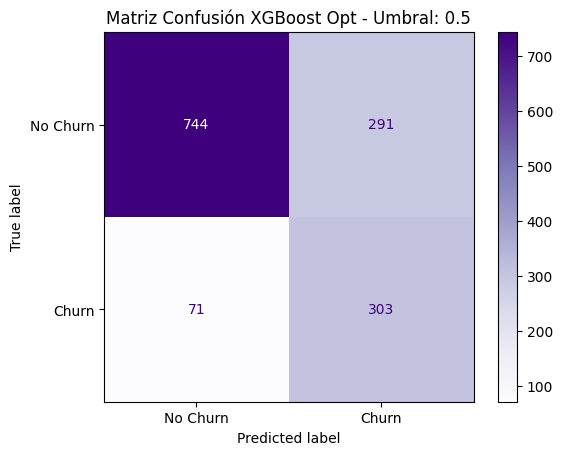

In [37]:
xgb_opt_resultado = evaluar_modelo(xgb_opt, X_train, y_train, X_test, y_test, threshold=.5, nombre_modelo='XGBoost Opt')

Una vez entrenado el modelo completo con los mejores parámetros encontrados se puede ver como estamos ante el modelo que más convergencia ha presentado entre el conjunto de entrenamiento y validación. El overfitting que presenta es inexistente, sin duda estamos ante el mejor modelo desarrollado hasta el momento, su capacidad de generalización destaca sobre el resto.

Si observamos el recall de la clase 1, supera el 80%, por tanto estamos siendo capaces de detectar 80 de cada 100 clientes que se dan de baja de la compañía. Cómo ya se ha mencionado anteriormente, reducir los FN va acompañado de un aumento de los FP, que es el precio a pagar. En este modelo tenemos el mayor número de FP hasta el momento, un precio que sin duda vale la pena pagar.

De momento estamos ante el modelo más robusto, al igual que con el RF, hay que intentar reducir el tamaño de variables para reducir la complejidad del modelo, lo que ayudará a su mantenimiento e implicará un menor coste. Para ello vamos a seleccionar las 10 variables más relevantes para el modelo haciendo uso de nuevo de la librería SHAP.

### Modelo Reducido XGBoost

In [38]:
# 1. Calculamos SHAP values para el modelo de 30 variables
explainer = shap.TreeExplainer(xgb_opt)
shap_values = explainer.shap_values(X_test)

# 2. Obtenemos la importancia media absoluta de cada variable
vals = np.abs(shap_values).mean(0)
feature_importance = pd.DataFrame(list(zip(X_train.columns, vals)), columns=['col_name','feature_importance_vals'])
feature_importance.sort_values(by=['feature_importance_vals'], ascending=False, inplace=True)
print(feature_importance.head(10))
# 3. Seleccionamos las 10 mejores
top_10_features = feature_importance['col_name'].head(10).values.tolist()

# 4. Creamos los nuevos conjuntos
X_train_xgb = X_train[top_10_features]
X_test_xgb = X_test[top_10_features]

                          col_name  feature_importance_vals
4                           tenure                 0.523885
19               Contract_Two year                 0.500036
16     InternetService_Fiber optic                 0.337314
18               Contract_One year                 0.226459
21  PaymentMethod_Electronic check                 0.203782
14                  MonthlyCharges                 0.161440
17              InternetService_No                 0.158550
13                PaperlessBilling                 0.132050
7                   OnlineSecurity                 0.097785
15                    TotalCharges                 0.095806


Una vez detectadas las 10 variables más importantes para el XGBoost y comparando con las del RF, se puede observar que hacen uso de las mismas variables, aunque en distinto orden e importancia. Esto es una muy buena señal ya que muestra consistencia en los datos.

In [39]:
estudio_xgb_10 = optimizacion_optuna_xgb(X_train_xgb, y_train, 50)

xgb_10 = XGBClassifier(**estudio_xgb_10.best_params, scale_pos_weight=ratio_xg, random_state=42)
xgb_10.fit(X_train_xgb, y_train)

[I 2026-05-11 16:37:57,261] A new study created in memory with name: no-name-b4b76f81-98ec-4232-b8e9-b8c5babdbd43
[I 2026-05-11 16:37:58,053] Trial 0 finished with value: 0.8009721401758922 and parameters: {'n_estimators': 437, 'max_depth': 10, 'learning_rate': 0.1205712628744377, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'gamma': 0.031198904067240532}. Best is trial 0 with value: 0.8009721401758922.
[I 2026-05-11 16:37:58,352] Trial 1 finished with value: 0.8271274159986406 and parameters: {'n_estimators': 152, 'max_depth': 9, 'learning_rate': 0.07725378389307355, 'subsample': 0.8540362888980227, 'colsample_bytree': 0.5102922471479012, 'gamma': 0.19398197043239887}. Best is trial 1 with value: 0.8271274159986406.
[I 2026-05-11 16:37:59,044] Trial 2 finished with value: 0.8402139466446538 and parameters: {'n_estimators': 850, 'max_depth': 4, 'learning_rate': 0.01855998084649059, 'subsample': 0.5917022549267169, 'colsample_bytree': 0.6521211214797689, 'gam

Mejor ROC AUC medio en CV: 0.8457
Mejores parámetros: {'n_estimators': 781, 'max_depth': 3, 'learning_rate': 0.01278665005089555, 'subsample': 0.7043086686248514, 'colsample_bytree': 0.7607062078731782, 'gamma': 0.18838564282267148}


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7607062078731782
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import 

XGB OPT 10
ROC AUC Train: 0.8695
ROC AUC Test: 0.8425

Informe Clasificación (Test):
              precision    recall  f1-score   support

           0       0.91      0.72      0.81      1035
           1       0.51      0.80      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409



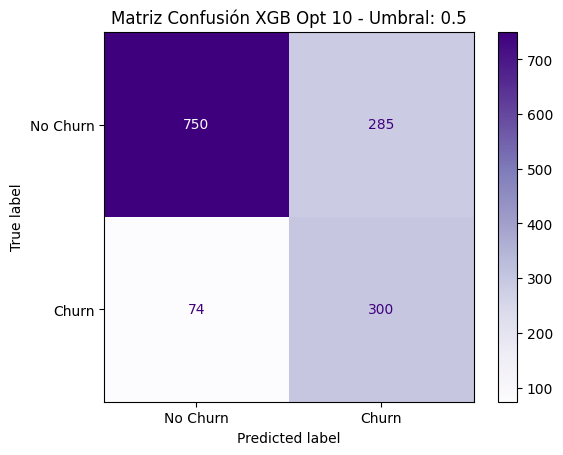

In [40]:
xgb_10_resultado = evaluar_modelo(xgb_10, X_train_xgb, y_train, X_test_xgb, y_test, threshold=.5, nombre_modelo='XGB Opt 10')

Observando el modelo que hace uso de 10 variables, los resultados que se logran son prácticamente idénticos. Observando el recall se puede ver que pasa del 81% al 80%, un empeoramiento totalmente rentable a cambio de reducir la complejidad del modelo a 10 variables, permitiendo que la explicación del mismo sea mucho más sencilla.

Ante esta situación, el modelo ganador que se llevará a producción es sin duda el XGBoost de 10 variables.

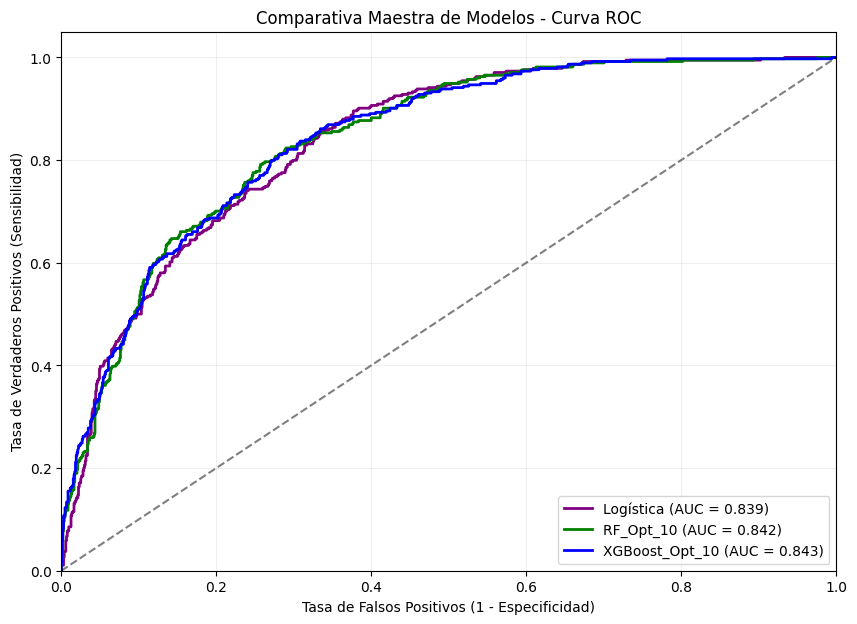

In [41]:
resultados_modelos = {} # diccionario para guardar los resultados de cada modelo

# Guardamos resultado regresión logística
resultados_modelos['Logística'] = y_probs_test
resultados_modelos['RF_Opt_10'] = rf_10_features
resultados_modelos['XGBoost_Opt_10'] = xgb_10_resultado

comparar_curvas_roc(resultados_modelos, y_test)

Como comparativa final, se muestra la curva ROC AUC de cada versión "seleccionada" de un algoritmo. Esta curva permite de forma visual ver que tan bueno es el modelo separando los clientes. En el eje Y se muestra la sensibilidad, que ha sido una de las medidas referencia hasta el momento y nos indica la capacidad que tiene el modelo para encontrar a los clientes que realmente se van (TP) y en el eje X se muestran las falsas alarmas, clientes que no se van pero el modelo dijo que si (FP). La línea diagonal que cruza el gráfico es el umbral de 0.5, si el resultado de la curva se encuentra en el mismo punto que la línea diagonal, el resultado del modelo sería tan fiable como lanzar una moneda al aire.

Observando las curvas, es difícil determinar si hay una mejor o peor. Que los 3 modelos convergan sobre el mismo punto indica que la señal de Churn ha sido captura en su totalidad por los datos disponibles. A diferencia de la regresión logística, los modelos basados en árboles son capaces de minimizar los falsos negativos, apreciación que se puede observar si nos fijamos en la parte inicial de la curva, en donde las curvas que representan estos modelos de árboles ganan a la logística. La principal ventaja que presenta la logística es su fácil interpretabilidad.

Llevar el modelo a producción por si solo no genera ninguna utilidad, es importante saber detectar los clientes que se van a ir, pero resulta más importante saber el motivo. Ahí es donde entre en juego la siguiente parte, en donde se busca obtener que variables inffluyen de forma positiva y negativa para que el ciente decida quedarse o irse. Con esa información el equipo comercial será capaz de crear una estrategia para cada tipo de cliente.

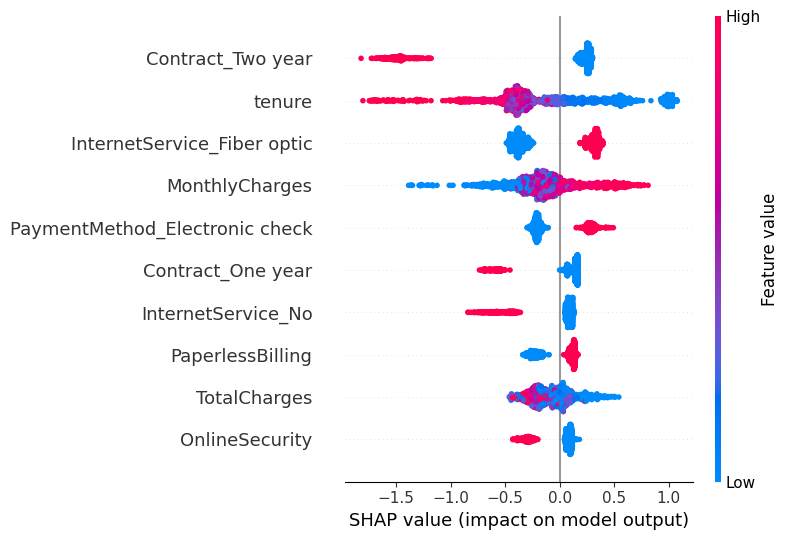

In [42]:
shap.initjs()

# 1. Creamos el objeto para descomponer resultados
explainer = shap.TreeExplainer(xgb_10) 

# 2. Calculamos los valores SHAP para el conjunto de test
# Indica impacto de cada variable en resultado final
shap_values = explainer.shap_values(X_test_xgb)

# Mostramos gráfico de como afectan las variables
shap.summary_plot(shap_values, X_test_xgb)

# Mostramos explicación para el primer cliente.
shap.force_plot(explainer.expected_value, shap_values[0,:], X_test_xgb.iloc[0,:])


##### NOTA: este gráfico se muestra como imagen estática para evitar problemas de visualización en GitHub
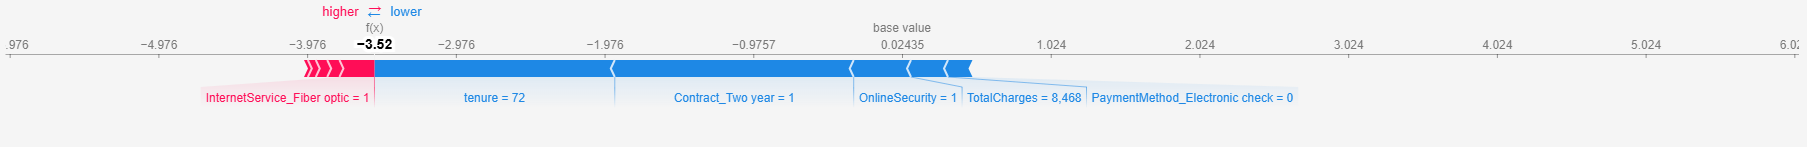

Observando el gráfico anterior el equipo de marketing ya puede tener una idea de cuales son los motivos por el que cada cliente decide irse. Cada punto en el gráfico es un cliente diferente.
La diferencia entre colores indica si esa variable tiene un valor alto o bajo. Claro que para la mayoría de las variables que aquí se muestran eso no aplica ya que están codificadas con 0 y 1. Para este escenario de variables codificadas el color solo muestra si tienen o no ese servicio. 
Por ejemplo, la variable "Contract_Two year" es una variable codificada. Los valores rojos indican que el cliente tiene esa modalidad de contrato. Cuanto más a la izquierda se encuentre el punto indica que las posibilidades de que el cliente se vaya es menor, siendo todo lo contrario una situación en donde los puntos se encuentren a la derecha, en donde las probabilidades de que el cliente se vaya aumentan.

Por otro lado, el orden en que se muestran las variables no es aleatorio, están ordenadas de mayor importancia a menor importancia. Observemos la tercera variable, en donde se indica si el cliente tiene contratada fibra óptica. Se puede ver que los puntos rojos, que indican que si tiene el servicio contratado, se encuentran a la derecha por tanto esto es algo a observar muy de cerca. Nos está indicando que los que han contratado la fibra óptica con la compañia no están contentos con ese servicio y es uno de los principales motivos para darse de baja. Ser conocedor de este detalle no solo sirve para el equipo de marketing, también es una información muy relevante para los directivos ya que se está mostrando un tipo de servicio que urge mejorar.

En el segundo gráfico se puede observar la influencia de cada variable para cada cliente de forma individual (este gráfico es mejor consumirlo en un panel interactivo donde se puede cambiar cada cliente de forma dinámica). En el gráfico se puede observar un valor base, que es el valor que prediciría el modelo por defecto si no tuviese ningún tipo de información sobre el cliente.
En este cliente, se puede ver como tiene contrato a dos años y una antigüedad de 72 meses, lo que empuja con mucho peso a que el cliente no tenga pensado darse de baja.

En conclusión, si el primer gráfico nos devuelve una idea global de que variables son las que más afectan a que los clientes se vayan o se queden, el segundo gráfico permitirá tener una estrategia clara para cada cliente. Cada cliente tendrá un motivo diferente para darse de baja, por tanto gracias al gráfico global se pueden diseñar diferentes estrategias de retención y con el gráfico individual saber que estrategia aplicar a la hora de contactar al cliente.

NOTA: estos gráficos confirman uno de los aspectos detectados tanto en la matriz de correlación, como en el DF filtrado con los hallazgos del boxplot sobre los cargos totales, aquellos que contratan la fibra óptica no están nada satisfechos y es el principal condicionante para que un cliente decida darse de baja.

In [43]:
variables_binarias = [col for col in X_train_xgb.columns if col not in ['tenure', 'TotalCharges','MonthlyCharges']]

resultados = []

for var in variables_binarias:
    # Cálculo la media variables binarias SHAP
    stats = df_eda.groupby(var)['Churn'].mean() * 100
    resultados.append({
        'Variable': var,
        'Tasa Churn (Si tiene)': stats.get(1, 0),
        'Tasa Churn (No tiene)': stats.get(0, 0),
        'Diferencia': stats.get(1, 0) - stats.get(0, 0)
    })

df_impacto_real = pd.DataFrame(resultados).sort_values(by='Diferencia', ascending=False)
df_impacto_real

,Variable,Tasa Churn (Si tiene),Tasa Churn (No tiene),Diferencia
3,PaymentMethod_Electronic check,45.285412,17.058572,28.226840
1,InternetService_Fiber optic,41.892765,14.492019,27.400746
5,PaperlessBilling,33.565092,16.330084,17.235009
6,OnlineSecurity,14.611194,31.329618,-16.718424
2,Contract_One year,11.269518,30.574506,-19.304988
4,InternetService_No,7.404980,31.828893,-24.423912
0,Contract_Two year,2.831858,34.050112,-31.218254


Por último, para cerrar el ejercicio, se calcula una tabla para obtener la tasa de abandono que representa tener contratado cada servicio de los que se muestran en el gráfico SHAP.

Se puede observar como aquellos que tienen un contrato a dos años, solo tienen una tasa de abandono del 3% aproximadamente, lo que confirma la importancia de este tipo de contrato a la hora de determinar que es un cliente fidelizado. En otras palabras, se puede decir que sólo 3 de cada 100 clientes con este tipo de contrato deciden irse.

Para la fibra óptica se puede apreciar muy bien como tener este servicio contratado aumenta las posibilidades de fuga en un 42%. Situación similar para los clientes que usan el método de pago de cheque electrónico, método que consiste en tener que rellenar los datos de forma manual cada 30 días en la página web de la empresa para realizar el pago del servicio contratado. Un método que ya de por sí puede generar bastante fricción al cliente por el proceso manual cada 30 días. En este caso, los clientes que usan este método tienen un 45% de probabilidades de fuga. Este método de pago como se aprecia en la matriz de correlación se encuentra fuertemente asociado a los contratos mes a mes.

Otro dato curioso a destacar es como aquellos clientes que no tienen factura en papel, tienen un 33% de probabilidades de irse, variable que se encuentra también correlacionada con la fibra óptica y el pago con cheque electrónico. Puede que este tipo de clientes pertenezcan a un segmento de baja edad que buscan optimizar sus gastos y que se manejan con mayor facilidad a la hora darse de baja y contratar un nuevo servicio.

In [49]:
import joblib

# Guardamos el modelo, el escalador (si usaste uno) y la lista de variables
export_data = {
    'model': xgb_10,
    'features': top_10_features
}

joblib.dump(export_data, 'modelo_churn_final.pkl')
print("¡Modelo exportado con éxito!")

¡Modelo exportado con éxito!


In [ ]:
X_test_xgb.to_csv('datos_test_dashboard.csv', index=True)
